<a href="https://colab.research.google.com/github/nivedhakrishnamurthy1-hue/Deep-Learning-24BAD082/blob/main/Perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **K.Nivedha (24BAD082)**

# **24ADI006-DEEP LEARNING**

# ***Perceptron Implementation - Worksheet1***

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

class Perceptron:
    """
    Single Layer Perceptron Classifier.

    Parameters:
    -----------
    learning_rate : float, default=0.1
        Step size for weight updates (eta).
    epochs : int, default=100
        Maximum passes over the training dataset.
    """
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _step_function(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                # Calculate linear output: z = w.x + b
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self._step_function(linear_output)

                # Weight and bias update rule
                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

                if update != 0:
                    errors += 1

            # Early stopping if all training samples are correctly classified
            if errors == 0:
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._step_function(linear_output)

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y) * 100

# **TASK 1:**

In [12]:
# 1. Inputs and Targets for Logic Gates
X_logic = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_and = np.array([0, 0, 0, 1])
y_or  = np.array([0, 1, 1, 1])

# --- Train AND Gate ---
perceptron_and = Perceptron(learning_rate=0.1, epochs=10)
perceptron_and.fit(X_logic, y_and)
pred_and = perceptron_and.predict(X_logic)
acc_and = perceptron_and.accuracy(X_logic, y_and)

# --- Train OR Gate ---
perceptron_or = Perceptron(learning_rate=0.1, epochs=10)
perceptron_or.fit(X_logic, y_or)
pred_or = perceptron_or.predict(X_logic)
acc_or = perceptron_or.accuracy(X_logic, y_or)

# Print Results
print("=== Task 1: Logic Gates ===")
print("\n[AND Gate Results]")
for x, p, y in zip(X_logic, pred_and, y_and):
    print(f"Input: {x} -> Predicted: {p} | Expected: {y}")
print(f"AND Gate Accuracy: {acc_and:.2f}%")

print("\n[OR Gate Results]")
for x, p, y in zip(X_logic, pred_or, y_or):
    print(f"Input: {x} -> Predicted: {p} | Expected: {y}")
print(f"OR Gate Accuracy: {acc_or:.2f}%")

=== Task 1: Logic Gates ===

[AND Gate Results]
Input: [0 0] -> Predicted: 0 | Expected: 0
Input: [0 1] -> Predicted: 0 | Expected: 0
Input: [1 0] -> Predicted: 0 | Expected: 0
Input: [1 1] -> Predicted: 1 | Expected: 1
AND Gate Accuracy: 100.00%

[OR Gate Results]
Input: [0 0] -> Predicted: 0 | Expected: 0
Input: [0 1] -> Predicted: 1 | Expected: 1
Input: [1 0] -> Predicted: 1 | Expected: 1
Input: [1 1] -> Predicted: 1 | Expected: 1
OR Gate Accuracy: 100.00%


# **TASK 2:**

=== Task 2: Random Dataset Results ===
Learned Weights : [ 0.10050283 -0.0483318 ]
Learned Bias    : 0.0100
Training Accuracy: 100.00%
Testing Accuracy : 100.00%

=== Confusion Matrix ===
[[23  0]
 [ 0 17]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



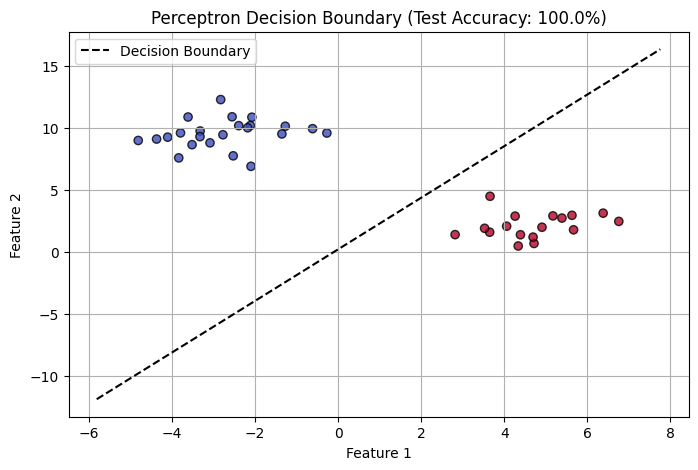

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------------------------------------------------
# 1. Perceptron Class Definition
# -------------------------------------------------------------------------
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def _step_function(self, z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(self.epochs):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self._step_function(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

                if update != 0:
                    errors += 1

            # Early stopping if fully converged
            if errors == 0:
                break

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self._step_function(linear_output)

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y) * 100


# -------------------------------------------------------------------------
# 2. Dataset Generation and Train-Test Split
# -------------------------------------------------------------------------
# Generate synthetic binary dataset (200 samples, 2 features)
X_rand, y_rand = make_blobs(
    n_samples=200,
    centers=2,
    n_features=2,
    cluster_std=1.2,
    random_state=42
)

# Split dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_rand, y_rand, test_size=0.2, random_state=42
)

# -------------------------------------------------------------------------
# 3. Model Training & Prediction
# -------------------------------------------------------------------------
perceptron_random = Perceptron(learning_rate=0.01, epochs=100)
perceptron_random.fit(X_train, y_train)

# Predictions on training and test sets
y_train_pred = perceptron_random.predict(X_train)
y_test_pred = perceptron_random.predict(X_test)

train_acc = perceptron_random.accuracy(X_train, y_train)
test_acc = perceptron_random.accuracy(X_test, y_test)

# -------------------------------------------------------------------------
# 4. Evaluation Outputs
# -------------------------------------------------------------------------
print("=== Task 2: Random Dataset Results ===")
print(f"Learned Weights : {perceptron_random.weights}")
print(f"Learned Bias    : {perceptron_random.bias:.4f}")
print(f"Training Accuracy: {train_acc:.2f}%")
print(f"Testing Accuracy : {test_acc:.2f}%\n")

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred))

# -------------------------------------------------------------------------
# 5. Visualization: Plot Decision Boundary
# -------------------------------------------------------------------------
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.8)

    # Calculate decision boundary line: w1*x1 + w2*x2 + b = 0  =>  x2 = -(w1*x1 + b) / w2
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x1_vals = np.linspace(x1_min, x1_max, 100)
    w1, w2 = model.weights
    b = model.bias

    if w2 != 0:
        x2_vals = -(w1 * x1_vals + b) / w2
        plt.plot(x1_vals, x2_vals, 'k--', label='Decision Boundary')

    plt.title(f"Perceptron Decision Boundary (Test Accuracy: {test_acc:.1f}%)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(X_test, y_test, perceptron_random)